# Part 2: Exploratory Data Analysis
 visual distribution analyses, finding data trends, checking target balance, and studying feature relationships.


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px
import plotly.io as pio
warnings.filterwarnings('ignore')

pio.templates.default = 'plotly_dark'
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')


In [24]:
# Separate Column Types
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include='object').columns





In [25]:
# Target Variable Distribution
print('Target Distribution (Counts):')
print(df['Churn'].value_counts())

print('\nTarget Distribution (Percentage):')
print(df['Churn'].value_counts(normalize=True) * 100)



Target Distribution (Counts):
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Target Distribution (Percentage):
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [26]:
# Customer Churn Distribution
fig=px.histogram(df,
                x='Churn',
                color='Churn',
                text_auto=True,
                title='Customer Churn Distribution')

fig.show()




In [27]:

# Churn Percentage
fig=px.pie(df,
           names='Churn',
           hole=0.45,
           title='Customer Churn Percentage',
           color="Churn",
           color_discrete_map={
           "Yes": "#EF553B",
           "No": "#00CC96"
           }
           )
fig.update_layout(title_x=0.5)
fig.show()
fig.write_image("./EDA plots/customer_churn_percentage.png")


In [28]:
fig=px.histogram(df,
                 x='tenure',
                 nbins=30,
                 marginal='box',
                 title='Distribution of Customer Tenure',
                
                 )
fig.update_layout(title_x=0.5,template='plotly_dark')

fig.show()


In [29]:
#Tenure vs Churn
fig=px.box(df,
           x='Churn',
           y='tenure',
           color='Churn',
           title='Tenure Vs Churn',
           color_discrete_map={'Yes':'teal','No':'red'}
           )
           
fig.update_layout(title_x=0.5)


In [30]:
# Monthly Charges Distribution
fig=px.histogram(df,
                 x='MonthlyCharges',
                 nbins=30,
                 marginal='box',
                 title='Monthly Charges Distribution')
fig.show()

In [43]:
#MOnlthly charges vs Churn
fig=px.histogram(df,
                x='Churn',
                y='MonthlyCharges',
                color='Churn',
                title='Monthly Charges vs Churn',
                color_discrete_sequence = ["#00B4D8", "#FF6B6B"]

                )
fig.show()




In [32]:
# Contract vs Churn
fig=px.histogram(df,
                x='Contract',
                color='Churn',
                barmode='group',
                title='Contract Type vs Churn'
                  )
fig.show()

In [33]:
#Internet Service vs Churn
fig=px.histogram(df,
                x='InternetService',
                color='Churn',
                barmode='group',
                title='Internet Service vs Churn')
fig.update_layout(title_x=0.5)
fig.show()


In [34]:
#Online Security vs Churn
fig=px.histogram(df,
                x='OnlineSecurity',
                color='Churn',
                barmode='group',
                title='Online Security vs Churn')
fig.update_layout(title_x=0.5)
fig.show()

In [35]:

#Tech Support vs Churn
fig = px.histogram(
    df,
    x="TechSupport",
    color="Churn",
    barmode="group",
    title="Tech Support vs Churn"
)

fig.show()


In [36]:
# . Payment Method vs Churn
fig = px.histogram(
    df,
    x="PaymentMethod",
    color="Churn",
    barmode="group",
    title="Payment Method vs Churn"
)

fig.update_layout(xaxis_tickangle=-30)

fig.show()

In [37]:
# Senior Citizen vs Churn
fig = px.histogram(
    df,
    x="SeniorCitizen",
    color="Churn",
    barmode="group",
    title="Senior Citizen vs Churn",
    color_discrete_map={
    "No": "navy",
    "Yes": "coral"}
    )

fig.show()

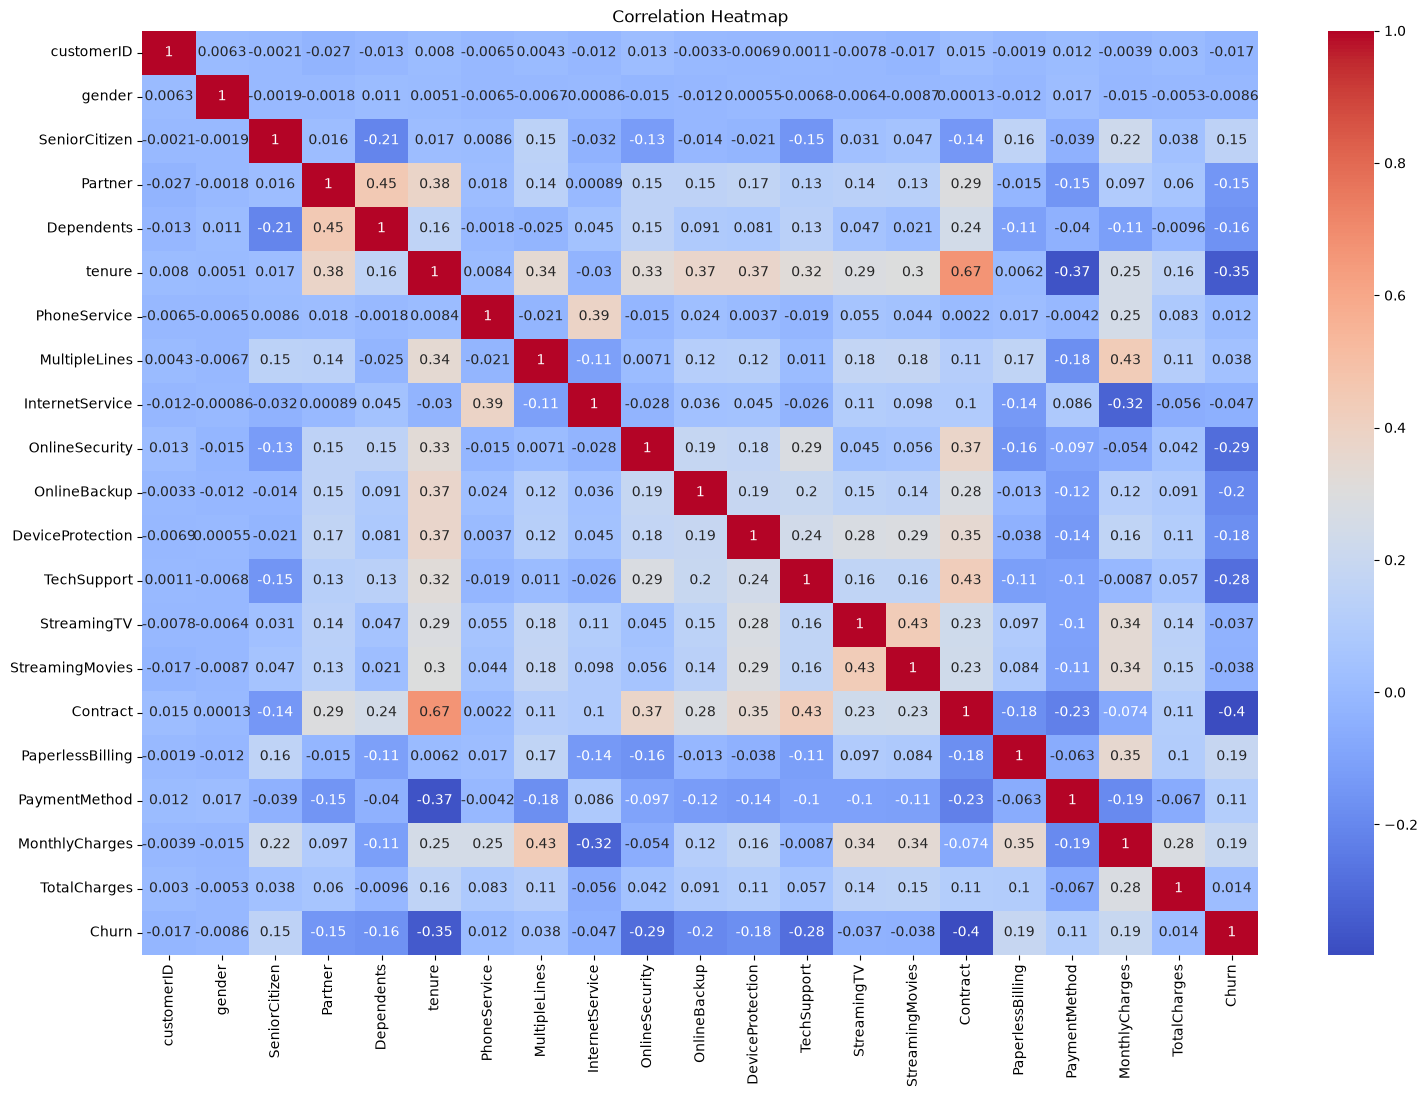

<Figure size 640x480 with 0 Axes>

In [38]:
#Correlation Heatmap
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

le = LabelEncoder()

for col in df_encoded.columns:
    if df_encoded[col].dtype == "object":
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

plt.figure(figsize=(18,12))
sns.heatmap(
    df_encoded.corr(),
    cmap="coolwarm",
    annot=True
)
plt.title("Correlation Heatmap")
plt.show()
plt.savefig('./EDA plots/correlation heatmap.png')

In [39]:
fig = px.histogram(
    df,
    x="InternetService",
    color="Churn",
    facet_col="Contract",
    barmode="group",
    title="Internet Service, Contract and Churn"
)
fig.update_layout(title_x=0.5)

fig.show()

In [40]:
service_cols = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["TotalServices"] = (
    df[service_cols]
    .replace({
        "Yes":1,
        "No":0,
        "No internet service":0,
        "No phone service":0
    })
    .sum(axis=1)
)



fig = px.box(
    df,
    x="Churn",
    y="TotalServices",
    color="Churn",
    title="Total Services vs Churn"
)

fig.show()